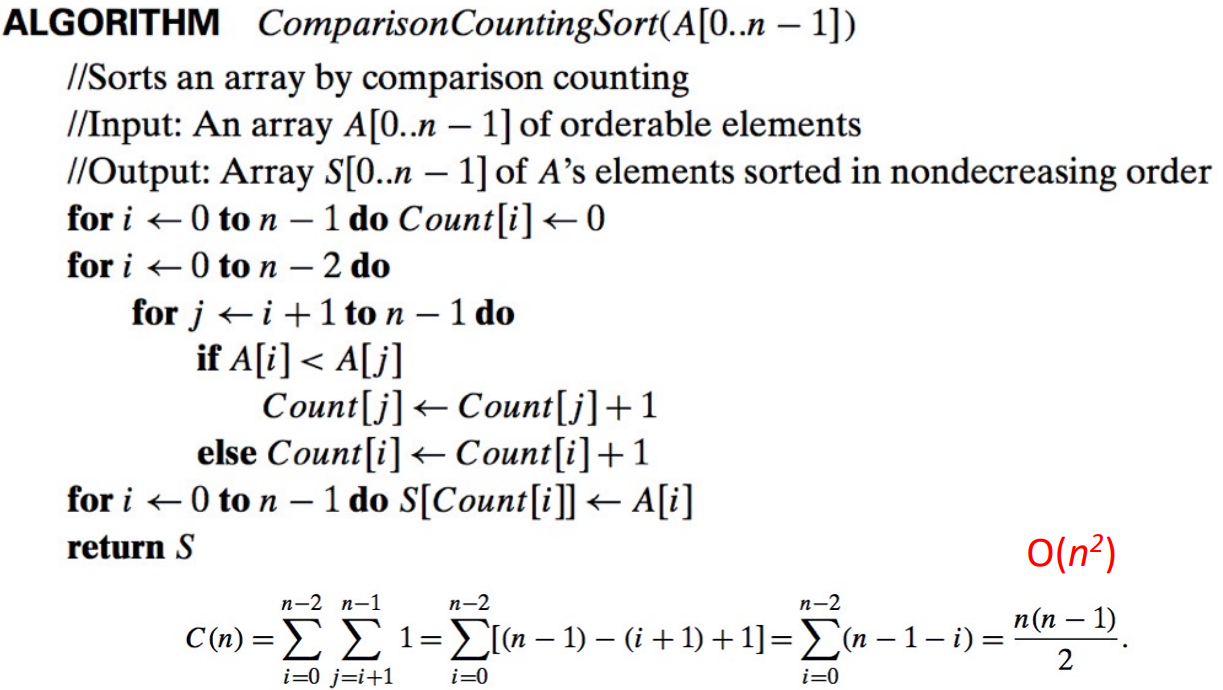

In [1]:
def ComparisonCountingSort(A):
    count = []
    S = [0] * len(A)
    for i in range(len(A)):
        count.append(0)
    for i in range(len(A)-1):
        for j in range(i+1,len(A)):
            if A[i] < A[j]:
                count[j] = count[j] + 1
            else:
                count[i] = count[i] + 1
    for i in range(len(A)):
        S[count[i]] = A[i]
    return S

In [2]:
ComparisonCountingSort([5, 2, 9, 1, 5, 6])

[1, 2, 5, 5, 6, 9]

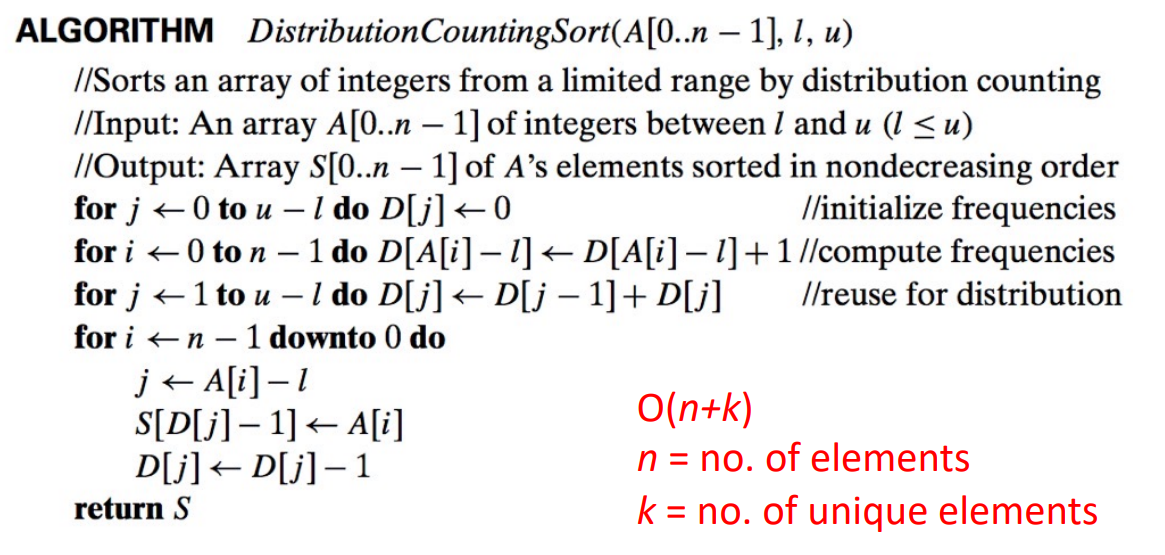

In [3]:
def DistributionCountingSort(A, l, u):
    D = []
    S = [0] * len(A)
    for j in range(u-l+1):
        D.append(0)
    for i in range(len(A)):
        D[A[i]-l] = D[A[i]-l] + 1
    for j in range(1, u-l+1):  
        D[j] = D[j-1] + D[j]
    for i in range(len(A)-1, -1, -1):
        j = A[i] - l
        S[D[j]-1] = A[i]
        D[j] = D[j] - 1 
        
    return S

In [4]:
DistributionCountingSort([5, 2, 9, 1, 5, 6],1,9)

[1, 2, 5, 5, 6, 9]

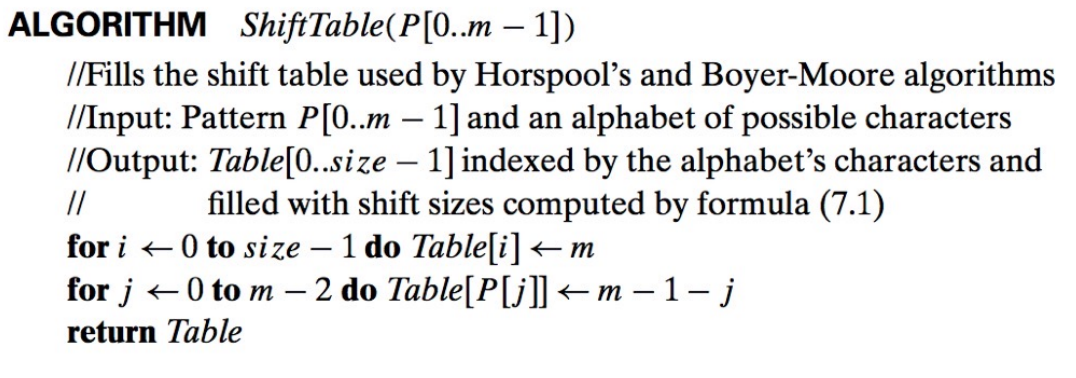

In [5]:
def ShiftTable(P):
    m = len(P)
    size = 256
    Table = [m] * size
    for j in range(m - 1):
        Table[ord(P[j])] = m - 1 - j
    return Table

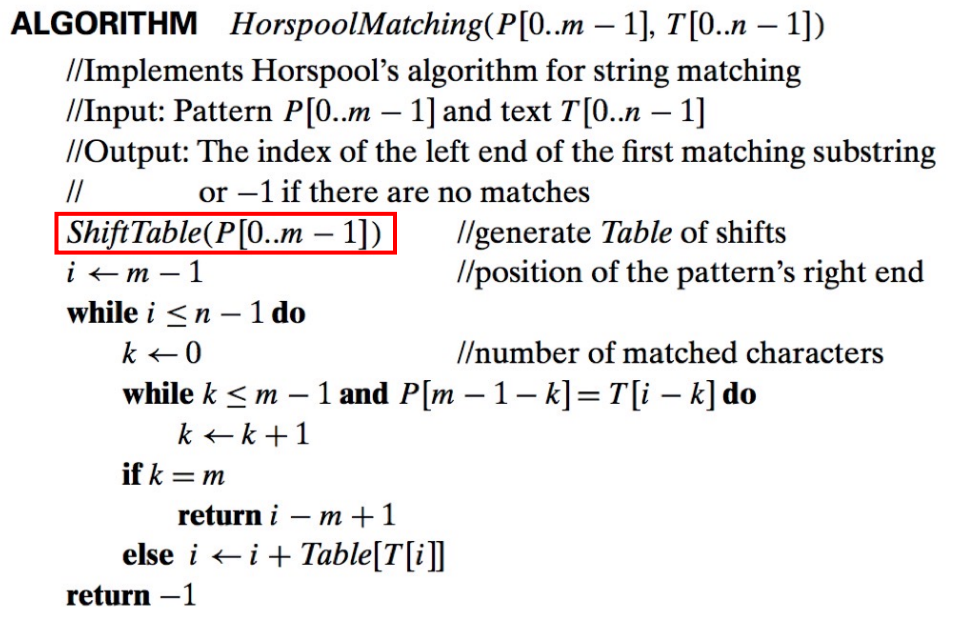

In [6]:
def HorspoolMatching(P, T):
    m = len(P) 
    n = len(T) 
    Table = ShiftTable(P) 
    i = m - 1  
    while i <= n - 1:
        k = 0  
        while k <= m - 1 and P[m - 1 - k] == T[i - k]:
            k += 1
        if k == m:
            return i - m + 1 
        else:
            i = i + Table[ord(T[i])] 
    return -1

In [9]:
text = "JIM_SAW_ME_IN_A_BARBERSHOP"
pattern = "BARBER"

result = HorspoolMatching(pattern, text)

print(f"ข้อความหลัก: {text}")
print(f"คำค้นหา: {pattern}")
print("-" * 30)

if result != -1:
    print(f"เจอคำค้นหาแล้ว! เริ่มต้นที่ Index: {result}")
    print(f"คำที่เจอคือ: '{text[result : result + len(pattern)]}'")
else:
    print("ไม่พบคำค้นหา")

ข้อความหลัก: JIM_SAW_ME_IN_A_BARBERSHOP
คำค้นหา: BARBER
------------------------------
เจอคำค้นหาแล้ว! เริ่มต้นที่ Index: 16
คำที่เจอคือ: 'BARBER'


In [10]:
def bad_symbol_table(P):
    m = len(P)
    size = 256
    Table = [m] * size
    for j in range(m - 1):
        Table[ord(P[j])] = m - 1 - j
    return Table

def good_suffix_table_baobab():
    return [0, 2, 5, 5, 5, 5] 

def BoyerMooreMatching(P, T):
    m = len(P)
    n = len(T)
    
    t1 = bad_symbol_table(P) 
    d2 = good_suffix_table_baobab()
    
    i = m - 1
    while i <= n - 1:
        k = 0
        while k < m and P[m - 1 - k] == T[i - k]:
            k += 1
        if k == m:
            return i - m + 1
        else:
            char_c = T[i - k]

            d1 = max(t1[ord(char_c)] - k, 1) 

            if k == 0:
                d = d1
            else:
                d = max(d1, d2[k])
                
            print(f"Mismatch ที่ Text index {i-k} ('{char_c}'), ค่า k={k} -> กระโดด {d} ช่อง")
            i += d # กระโดด!
    return -1

In [ ]:
text = "BESS KNEW ABOUT BAOBABS"
pattern = "BAOBAB"

print(f"ข้อความ: '{text}'")
print("-" * 40)
result = BoyerMooreMatching(pattern, text)

print("-" * 40)
if result != -1:
    print(f"เจอแล้ว! เริ่มต้นที่ Index: {result}")
else:
    print("ไม่พบคำค้นหา")

ข้อความ: 'BESS KNEW ABOUT BAOBABS'
----------------------------------------
Mismatch ที่ Text index 5 ('K'), ค่า k=0 -> กระโดด 6 ช่อง
Mismatch ที่ Text index 9 (' '), ค่า k=2 -> กระโดด 5 ช่อง
Mismatch ที่ Text index 15 (' '), ค่า k=1 -> กระโดด 5 ช่อง
----------------------------------------
✅ เจอแล้ว! เริ่มต้นที่ Index: 16
